___
# <span style="color:darkgreen">📊 Retail Analytics: Walmart Case Study</span>
___

### Step 3. Exploratory Data Analysis and Visualizations

**Goal**: Perform exploratory analysis to uncover insights into sales, profit, and product performance

**Analytical Method**
Performe analysis based on Sales, Profit, Prodcut base margin, customers, shipping cost and discounts  
1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis
4. Correlation Analysis 

##### Importing Liabraries and loading cleaned data set

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Display options and styles
pd.set_option('display.max_columns', None)                    #Shows all columns when printing dataframe
pd.set_option('display.float_format', lambda x: '%.2f' % x)   #Formats decimals to 2 places
plt.style.use('seaborn-v0_8-whitegrid')                       #Sets a clean chart style
plt.rcParams['figure.figsize'] = (10, 6)                      #Sets default chart size
plt.rcParams['font.size'] = 12                                #Sets default font size
sns.set_palette('husl')                                       #Sets color palette
print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
#Load the dataset
df = pd.read_csv('../data/Cleaned_Walmart Retail Data.csv', encoding='latin-1')
# Display dataset dimensions
print("Dataset loaded successfully!")
print("="*70)
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded successfully!
Dataset Shape: 8,399 rows × 25 columns


#### 3.1 Univariate Analysis

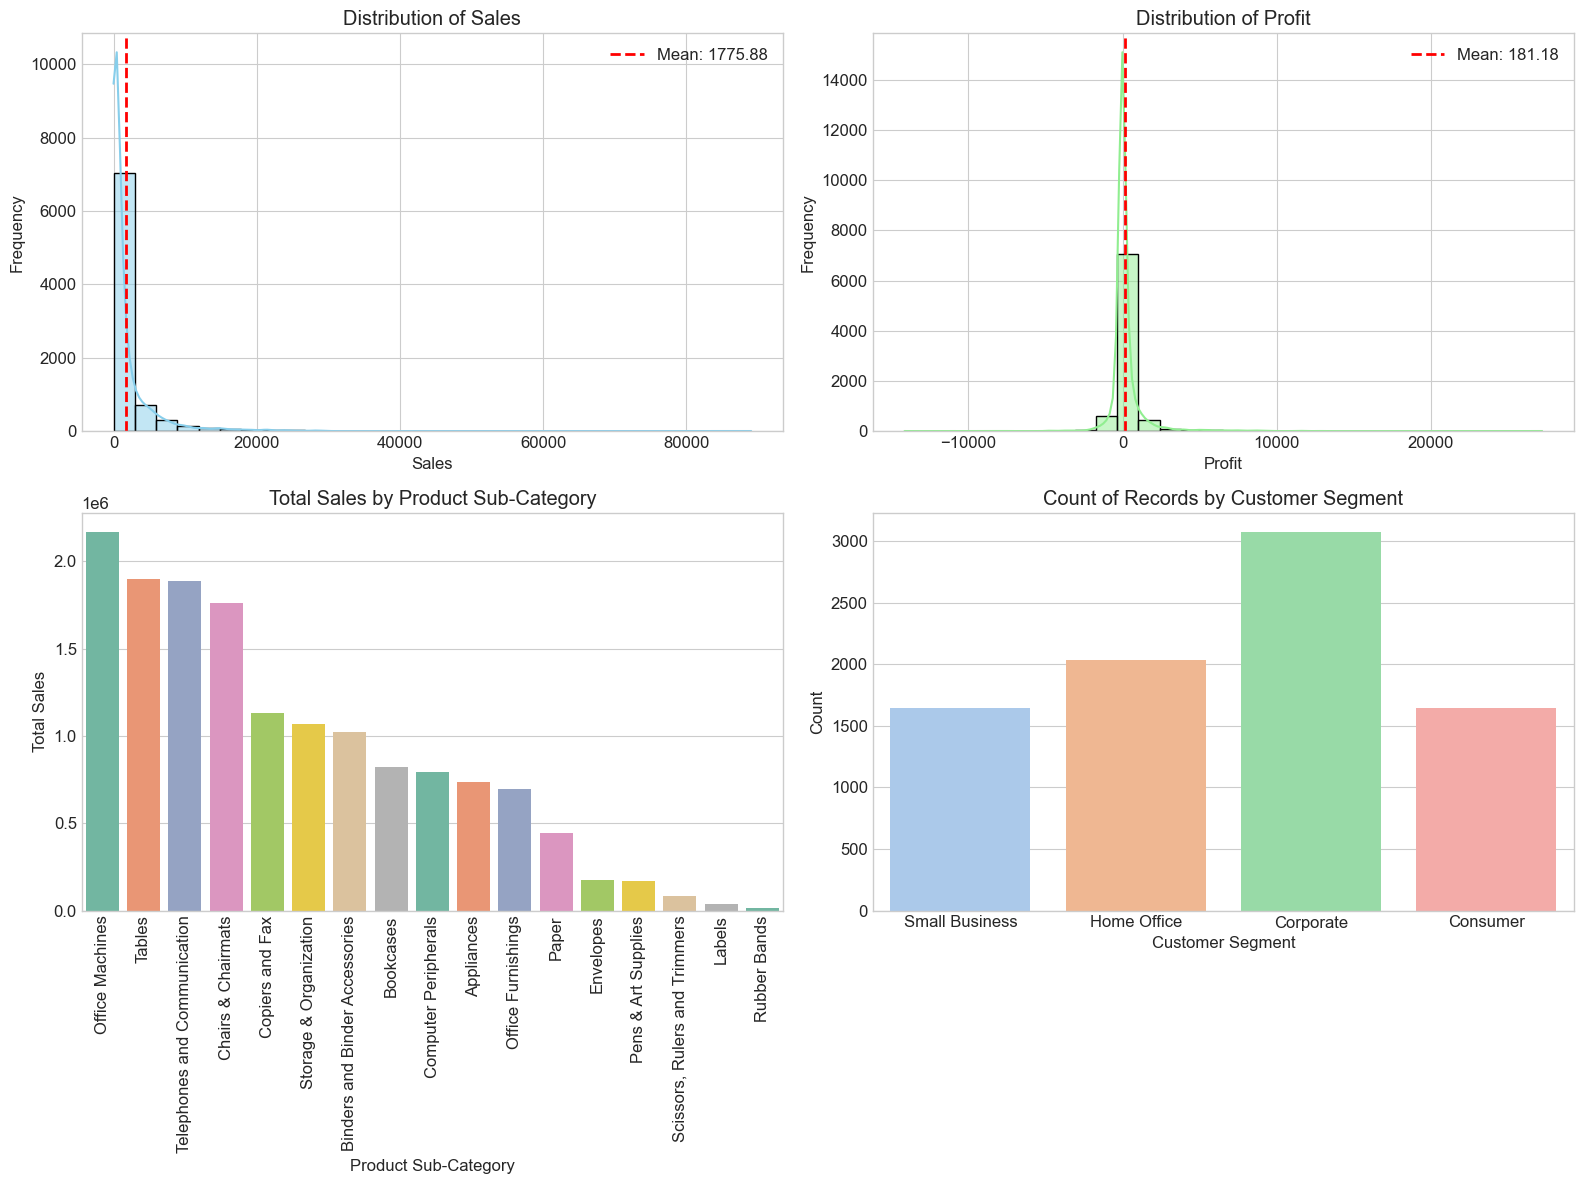

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. Histogram for Sales with mean line
sns.histplot(df['Sales'], bins=30, kde=True, color='skyblue', ax=axes[0,0])
axes[0,0].axvline(df['Sales'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {df['Sales'].mean():.2f}")
axes[0,0].set_title("Distribution of Sales")
axes[0,0].set_xlabel("Sales")
axes[0,0].set_ylabel("Frequency")
axes[0,0].legend()

# 2. Histogram for Profit with mean line
sns.histplot(df['Profit'], bins=30, kde=True, color='lightgreen', ax=axes[0,1])
axes[0,1].axvline(df['Profit'].mean(), color='red', linestyle='--', linewidth=2,
                  label=f"Mean: {df['Profit'].mean():.2f}")
axes[0,1].set_title("Distribution of Profit")
axes[0,1].set_xlabel("Profit")
axes[0,1].set_ylabel("Frequency")
axes[0,1].legend()

# 3. Bar Chart: Total Sales by Product Sub-Category
sales_summary = df.groupby('Product Sub-Category')['Sales'].sum().reset_index()
sales_summary = sales_summary.sort_values(by='Sales', ascending=False)

sns.barplot(data=sales_summary, x='Product Sub-Category', y='Sales',
            palette="Set2", ax=axes[1,0])
axes[1,0].set_title("Total Sales by Product Sub-Category")
axes[1,0].set_xlabel("Product Sub-Category")
axes[1,0].set_ylabel("Total Sales")
axes[1,0].tick_params(axis='x', rotation=90)

# 4. Count plot for Customer Segment
sns.countplot(x='Customer Segment', data=df, palette="pastel", ax=axes[1,1])
axes[1,1].set_title("Count of Records by Customer Segment")
axes[1,1].set_xlabel("Customer Segment")
axes[1,1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:lightyellow">
<h4>🔑 Key Insights provided below</h4>
<ul>
  <li>Right-skewed → Most sales are small, with a few very large ones stretching the distribution</li>
  <li>Mean ≈ 1775.88 → The average is pulled upward by high-value outliers</li>
  <li>Average Profit per sales is 181.18</li>
  <li>Office Machines is the product sub‑category with the highest sales</li>
  <li>Coporate group is contributed more customers</li>
 
</ul>
</div>


#### 3.2 Bivariate Analysis

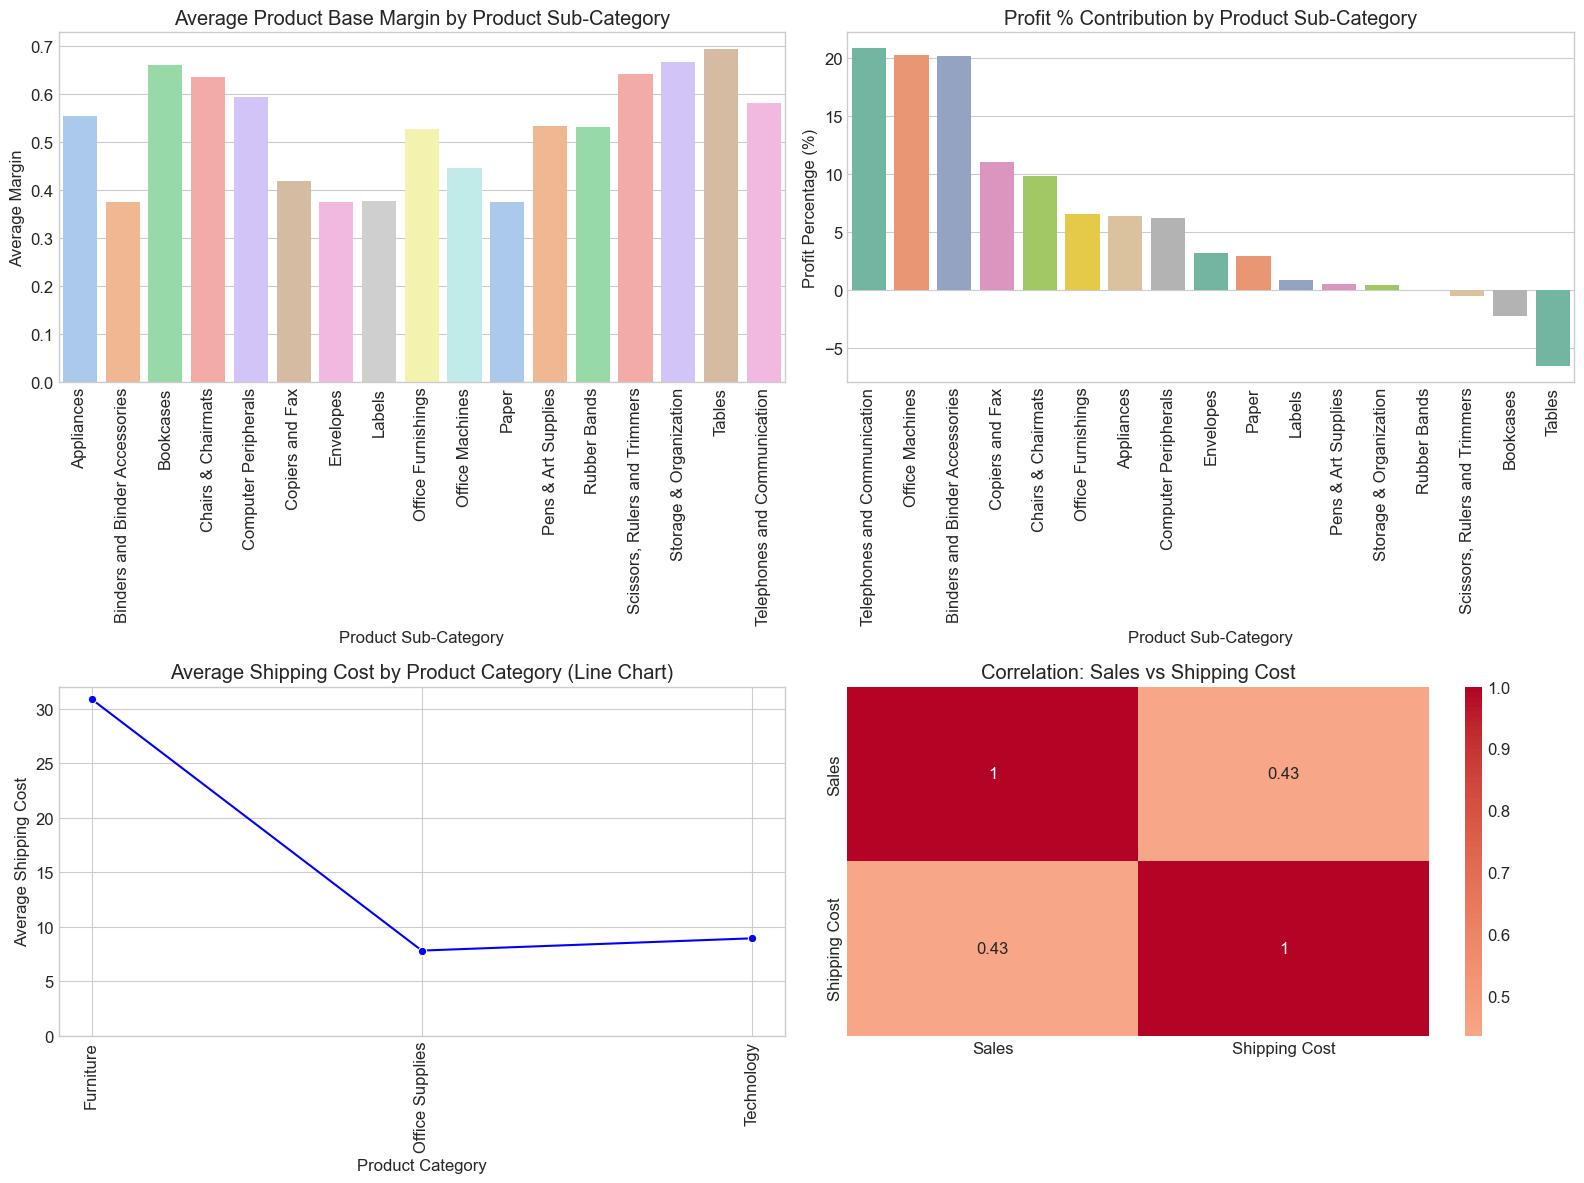

In [55]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. Bar Chart: Average Product Base Margin by Product Sub-Category
summary_margin = df.groupby('Product Sub-Category')['Product Base Margin'].mean().reset_index()
sns.barplot(data=summary_margin, x='Product Sub-Category', y='Product Base Margin',
            palette="pastel", ax=axes[0,0])
axes[0,0].set_title("Average Product Base Margin by Product Sub-Category")
axes[0,0].set_xlabel("Product Sub-Category")
axes[0,0].set_ylabel("Average Margin")
axes[0,0].tick_params(axis='x', rotation=90)

# 2. Bar Chart: Profit % Contribution by Product Sub-Category
profit_summary = df.groupby('Product Sub-Category')['Profit'].sum().reset_index()
total_profit = profit_summary['Profit'].sum()
profit_summary['Profit %'] = (profit_summary['Profit'] / total_profit) * 100
profit_summary = profit_summary.sort_values(by='Profit %', ascending=False)

sns.barplot(data=profit_summary, x='Product Sub-Category', y='Profit %',
            palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Profit % Contribution by Product Sub-Category")
axes[0,1].set_xlabel("Product Sub-Category")
axes[0,1].set_ylabel("Profit Percentage (%)")
axes[0,1].tick_params(axis='x', rotation=90)

# 3. Line Chart: Average Shipping Cost by Product Category
pivot_shipping = df.pivot_table(values='Shipping Cost',
                                index='Product Category',
                                aggfunc='mean').reset_index()

sns.lineplot(data=pivot_shipping,
             x='Product Category',
             y='Shipping Cost',
             marker='o',
             color='blue',
             ax=axes[1,0])
axes[1,0].set_title("Average Shipping Cost by Product Category (Line Chart)")
axes[1,0].set_xlabel("Product Category")
axes[1,0].set_ylabel("Average Shipping Cost")
axes[1,0].tick_params(axis='x', rotation=90)
axes[1,0].set_ylim(0)   # Force Y-axis to start at 0

# 4. Heatmap: Correlation between Sales & Shipping Cost
corr = df[['Sales','Shipping Cost']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title("Correlation: Sales vs Shipping Cost")

plt.tight_layout()
plt.show()



<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:lightyellow">
<h4>🔑 Key Insights provided below</h4>
<ul>
  <li>Margins → Sub‑categories like Appliances, Binders, and Chairs have higher average margins, while Envelopes and Labels are much lower</li>
  <li>Profit contribution → Telephones, Office Machines, and Binders drive the most profit, while Tables and Bookcases actually reduce overall profit</li>
  <li>Shipping cost → Furniture has the highest average shipping cost, followed by Technology; Office Supplies are cheapest to ship</li>
  <li>Correlation → Sales and Shipping Cost show a moderate positive relationship (0.43), meaning bigger sales orders tend to have higher shipping costs</li>
 <li>In short: High‑margin categories don’t always align with high profit contribution, shipping costs vary by category, and larger sales usually come with higher shipping costs.
 

  
 
</ul>
</div>

#### 3.3 Multivariate Analysis

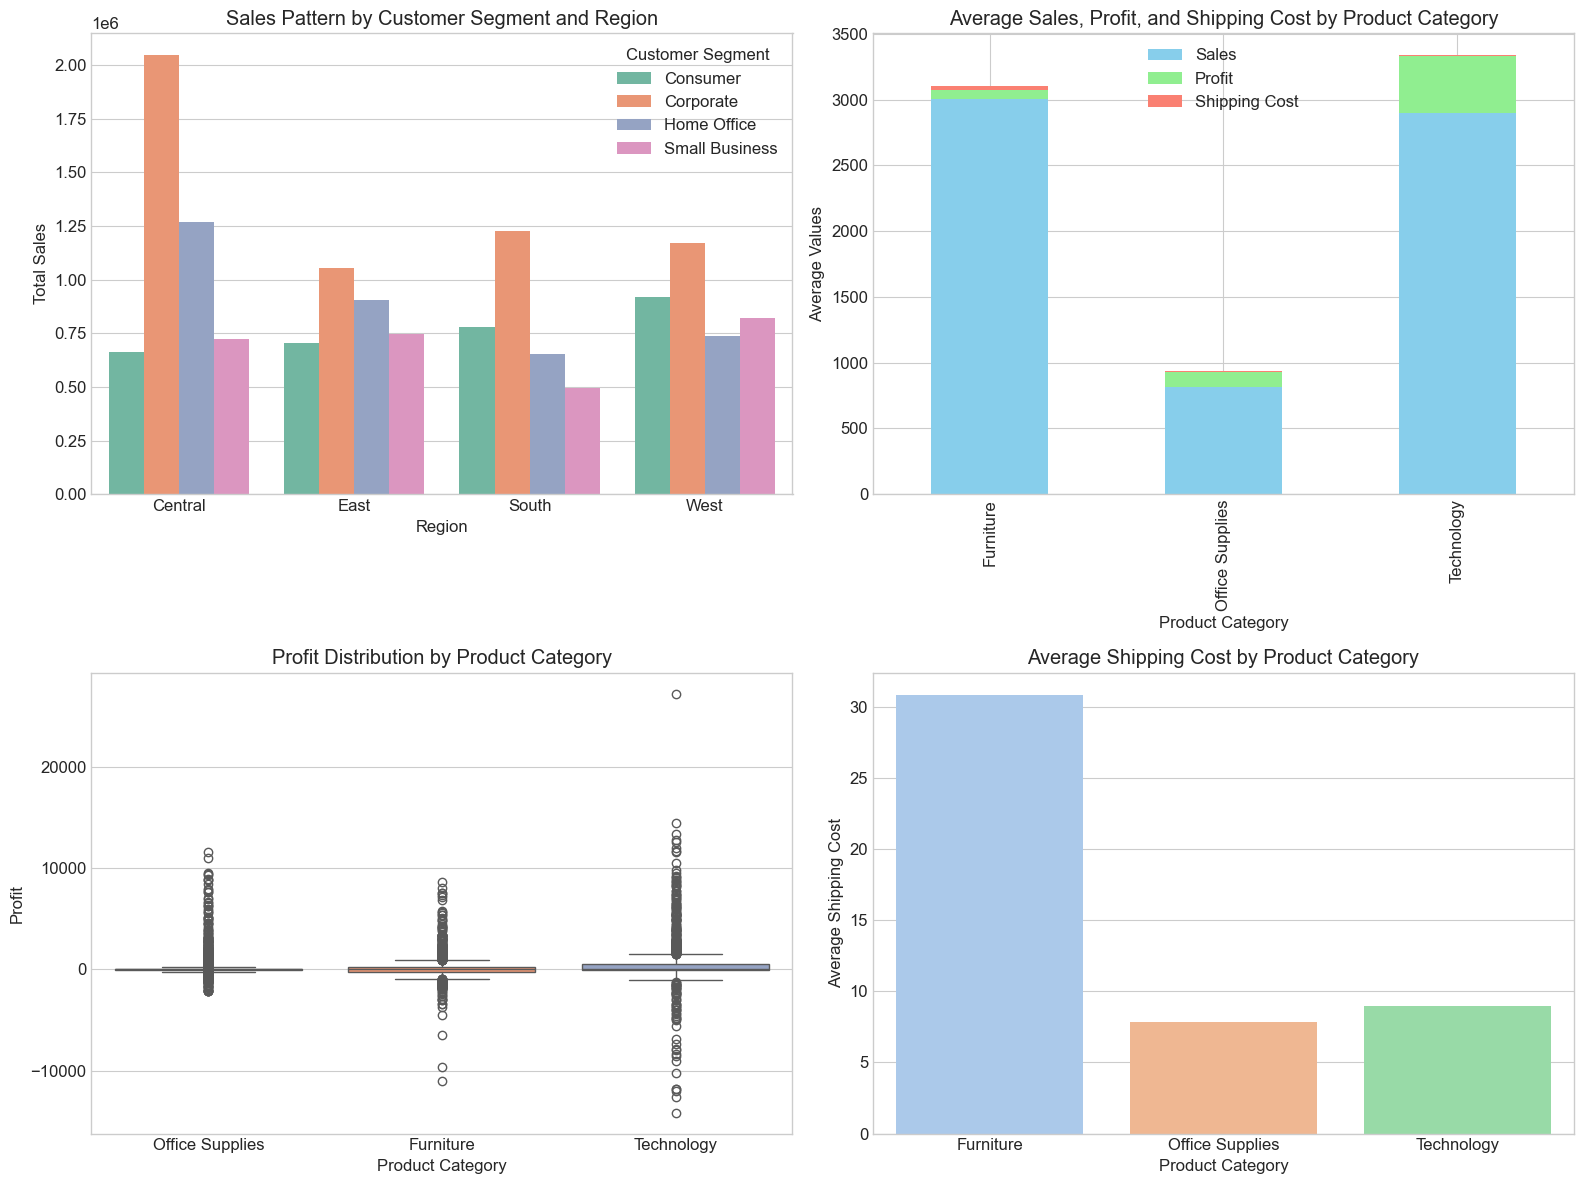

   Product Category            Product Sub-Category    Sales  Shipping Cost  Profit
0         Furniture                       Bookcases  4352.66          45.75 -177.68
1         Furniture              Chairs & Chairmats  4564.34          40.19  387.69
2         Furniture              Office Furnishings   885.91          10.66  127.45
3         Furniture                          Tables  5252.10          57.29 -274.41
4   Office Supplies                      Appliances  1698.14          15.79  223.87
5   Office Supplies  Binders and Binder Accessories  1117.99           7.25  335.97
6   Office Supplies                       Envelopes   707.67           6.84  195.86
7   Office Supplies                          Labels   135.35           1.00   47.49
8   Office Supplies                           Paper   364.45           6.46   36.95
9   Office Supplies             Pens & Art Supplies   263.99           3.23   11.95
10  Office Supplies                    Rubber Bands    83.84           1.26 

In [66]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. Bar Chart: Sales Pattern by Customer Segment and Region
sales_summary = df.groupby(['Region','Customer Segment'])['Sales'].sum().reset_index()
sns.barplot(data=sales_summary, x='Region', y='Sales', hue='Customer Segment',
            palette="Set2", ax=axes[0,0])
axes[0,0].set_title("Sales Pattern by Customer Segment and Region")
axes[0,0].set_xlabel("Region")
axes[0,0].set_ylabel("Total Sales")
axes[0,0].legend(title="Customer Segment")

# 2. Stacked Bar Chart: Average Sales, Profit, Shipping Cost by Product Category
summary_multi = df.groupby('Product Category').agg({
    'Sales':'mean',
    'Profit':'mean',
    'Shipping Cost':'mean'
}).reset_index()

summary_multi.set_index('Product Category').plot(
    kind='bar',
    stacked=True,
    color=['skyblue','lightgreen','salmon'],
    ax=axes[0,1]
)
axes[0,1].set_title("Average Sales, Profit, and Shipping Cost by Product Category")
axes[0,1].set_ylabel("Average Values")
axes[0,1].set_xlabel("Product Category")

# 3. Boxplot: Profit by Product Category
sns.boxplot(data=df, x='Product Category', y='Profit', palette="Set2", ax=axes[1,0])
axes[1,0].set_title("Profit Distribution by Product Category")

# 4. Bar Chart: Average Shipping Cost by Product Category
pivot_shipping = df.pivot_table(values='Shipping Cost', index='Product Category', aggfunc='mean')
sns.barplot(x=pivot_shipping.index, y=pivot_shipping['Shipping Cost'],
            palette="pastel", ax=axes[1,1])
axes[1,1].set_title("Average Shipping Cost by Product Category")
axes[1,1].set_ylabel("Average Shipping Cost")

plt.tight_layout()
plt.show()


# Group by Category and Sub-Category
summary = df.groupby(['Product Category', 'Product Sub-Category']).agg({
    'Sales': 'mean',
    'Shipping Cost': 'mean',
    'Profit': 'mean'
}).reset_index()

# Adjust display settings so all columns show in one row
import pandas as pd
pd.set_option('display.width', 2000)   # widen output
pd.set_option('display.max_columns', None)  # show all columns

print(summary)

<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:lightyellow">
<h4>🔑 Key Insights provided below</h4>
<ul>
  <li>Sales by Region & Segment → Corporate customers in the Central region generate the highest sales overall.</li>
  <li>Category averages → Technology delivers the highest average profit, while Furniture has the highest average shipping cost</li>
  <li>Profit distribution → All categories show wide profit variation, with both positive and negative outliers</li>
  <li>Shipping cost → Furniture is most expensive to ship, followed by Technology; Office Supplies are cheapest</li>
<li>In short: Corporate sales dominate in the Central region, Technology is most profitable, Furniture is costly to ship, and profit varies widely across categories
 
</ul>
</div>

#### 3.4 Correalation Analysis


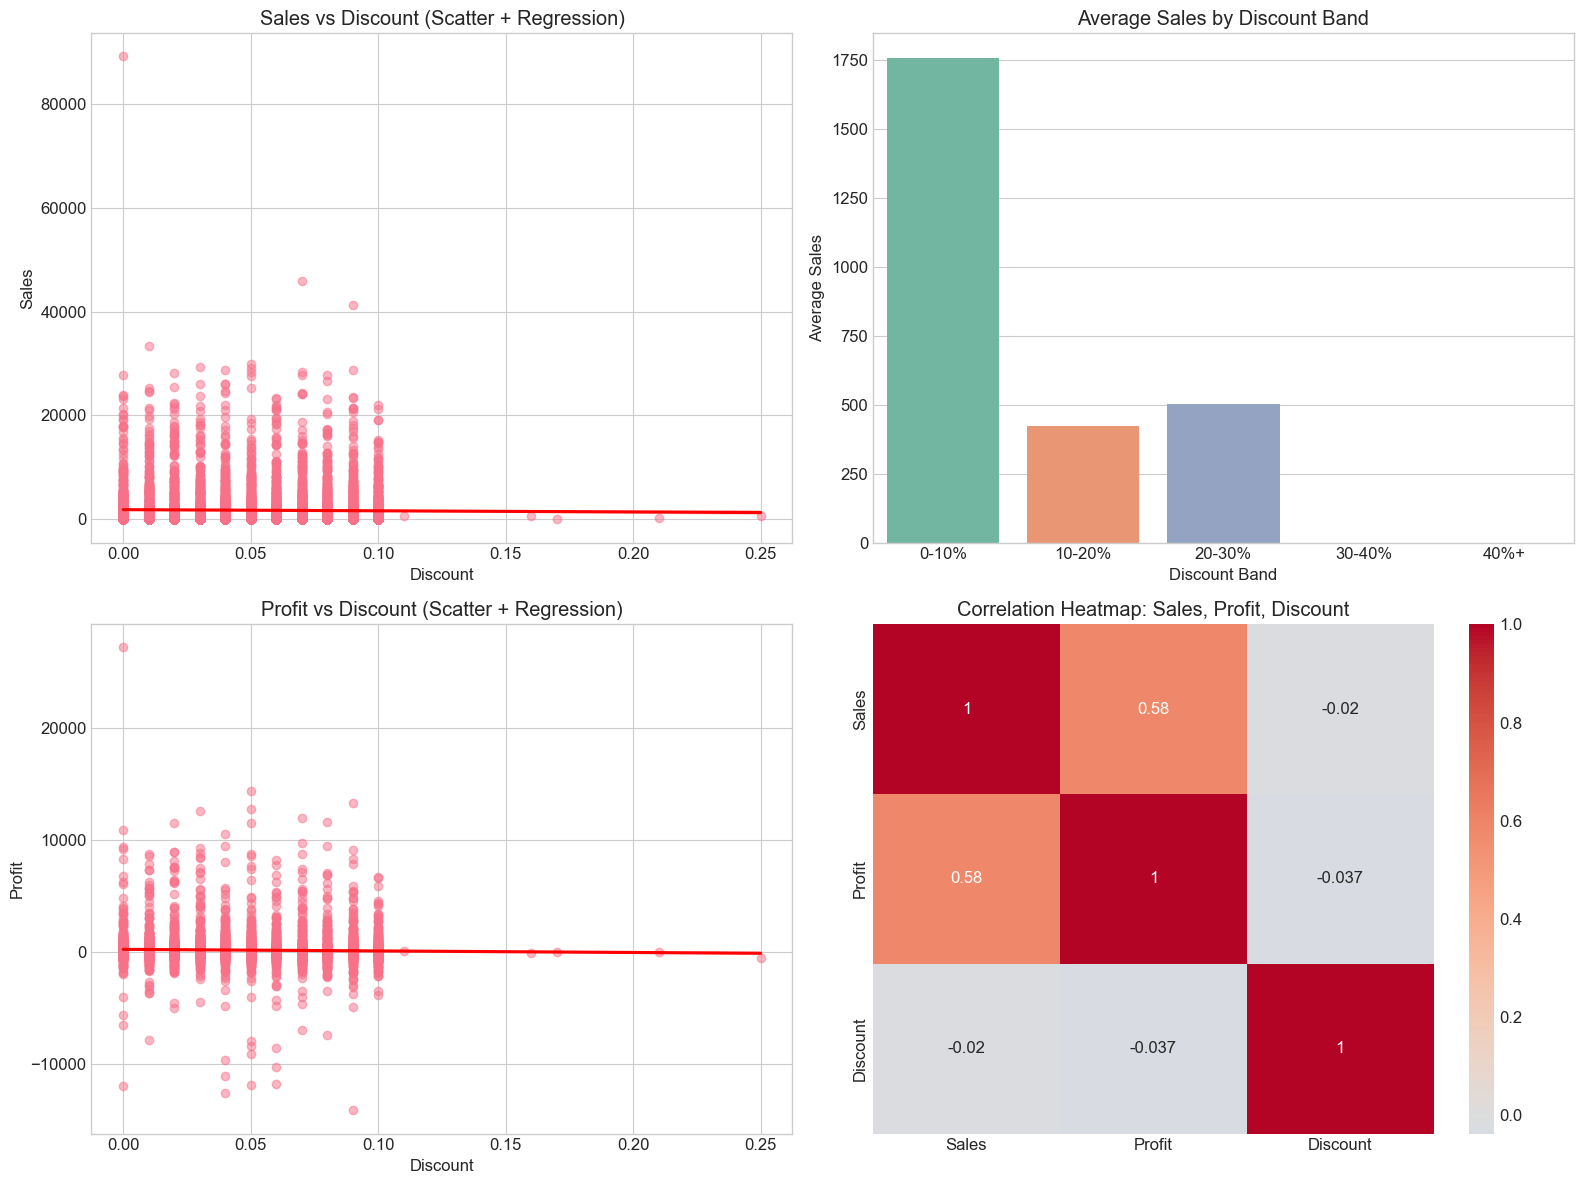

In [62]:
fig, axes = plt.subplots(2, 2, figsize=(16,12))

# 1. Scatter Plot: Sales vs Discount with regression line
sns.regplot(data=df, x='Discount', y='Sales',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[0,0])
axes[0,0].set_title("Sales vs Discount (Scatter + Regression)")
axes[0,0].set_xlabel("Discount")
axes[0,0].set_ylabel("Sales")

# 2. Bar Chart: Average Sales by Discount Band
df['Discount Band'] = pd.cut(df['Discount'],
                             bins=[0,0.1,0.2,0.3,0.4,1.0],
                             labels=['0-10%','10-20%','20-30%','30-40%','40%+'])
sales_by_band = df.groupby('Discount Band')['Sales'].mean().reset_index()

sns.barplot(data=sales_by_band, x='Discount Band', y='Sales',
            palette="Set2", ax=axes[0,1])
axes[0,1].set_title("Average Sales by Discount Band")
axes[0,1].set_xlabel("Discount Band")
axes[0,1].set_ylabel("Average Sales")

# 3. Scatter Plot: Profit vs Discount with regression line
sns.regplot(data=df, x='Discount', y='Profit',
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ax=axes[1,0])
axes[1,0].set_title("Profit vs Discount (Scatter + Regression)")
axes[1,0].set_xlabel("Discount")
axes[1,0].set_ylabel("Profit")

# 4. Heatmap: Correlation matrix (Sales, Profit, Discount)
corr = df[['Sales','Profit','Discount']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title("Correlation Heatmap: Sales, Profit, Discount")

plt.tight_layout()
plt.show()


<div style="border:1px solid #ccc; padding:10px; border-radius:5px; background-color:lightyellow">
<h4>🔑 Key Insights provided below</h4>
<ul>
  <li>Sales vs Discount (scatter) → No clear trend; discounts don’t significantly boost sales</li>
  <li>Average Sales by Discount Band → Highest average sales occur at low discounts (0–10%), and sales decline as discounts increase</li>
  <li>Sales & Profit: moderate positive correlation (0.58) → higher sales generally bring higher profit</li>
  <li>Sales & Discount: almost no correlation (-0.02) → discounts don’t drive sales</li>
  <li>Profit & Discount: very weak negative correlation (-0.04) → discounts slightly reduce profit but not strongly</li>
  <li>In Short: Discounts show little influence on sales and tend to slightly reduce profit. Sales and profit are moderately correlated, but discounts are not a key performance driver.
</ul>
</div>